# MotionHiFlow — Colab Reproduction & Benchmark Pipeline

This notebook is a **driver**. All reusable logic lives in `benchmark_utils.py`, so the
cells stay short and the code is version-controllable, importable from a plain script, and
testable outside Colab.

Two rules this split follows:

- **Generation goes through the repository's own scripts** (`run.sh` → `gen_t2m.py`).
  Nothing in the MotionHiFlow repo is edited, so `git pull` stays conflict-free.
- **Post-processing lives in `benchmark_utils.py`**, beside the repo rather than inside it,
  because none of it exists upstream: standardisation to a common coordinate frame,
  facing checks, GIF rendering with axis labels, and the per-prompt matching score.

---

## Recommended workflow

1. Start a fresh Colab **GPU** runtime.
2. Run **Steps 1 – 3**.
3. **Restart the session** (Runtime → Restart session) when Step 3 finishes.
4. Continue from **Step 4**.
5. Set the run parameters in the Run configuration cell, then work through Steps 7 – 11.

| Step | Content |
|---|---|
| 1 | Runtime check |
| 2 | Clone repository |
| 3 | Install dependencies (restart afterwards) |
| 4 | Verify imports after restart |
| 5 | NumPy visualization compatibility patch |
| 6 | Prepare evaluator, GloVe, CLIP and checkpoints |
| — | **Load `benchmark_utils.py` and set the run configuration** |
| 7 | Quick qualitative generation (optional) |
| 8 | Batch generation for the benchmark |
| 9 | Motion standardisation |
| 10 | Render standardised GIFs |
| 11 | Matching Score (optional) |

## 1. Check runtime

In [ ]:
import sys
import torch

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    # Without a GPU the generation step is extremely slow or unusable.
    print("WARNING: No GPU detected. Switch the Colab runtime to GPU.")

# This workflow was verified on Python 3.11.
if sys.version_info[:2] != (3, 11):
    print("\nWARNING: Python version differs from the verified 3.11 environment; "
          "the dependency pins below may need adjusting.")

Python : 3.11.13
PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## 2. Clone MotionHiFlow

Idempotent: reuse an existing clone, or remove a non-repository directory and clone again.

In [ ]:
%cd /content

from pathlib import Path

REPO = Path("/content/MotionHiFlow")

# run.sh marks a valid repository root.
if not (REPO / "run.sh").exists():
    if REPO.exists():
        print("Directory exists but is not the repository. Removing it first.")
        !rm -rf /content/MotionHiFlow
    !git clone https://github.com/ai-lh/MotionHiFlow.git

%cd /content/MotionHiFlow

# Integrity check: failing fast here is better than a confusing error several steps later.
REQUIRED_REPO_FILES = ["run.sh", "gen_t2m.py", "eval.py", "prepare.sh", "src", "configs"]
missing_repo_files = [x for x in REQUIRED_REPO_FILES if not Path(x).exists()]

if missing_repo_files:
    raise RuntimeError(f"Repository is incomplete. Missing: {missing_repo_files}")

print("MotionHiFlow repository is ready.")

/content
Cloning into 'MotionHiFlow'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 111 (delta 13), reused 110 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 941.11 KiB | 6.49 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/MotionHiFlow
MotionHiFlow repository is ready.


## 3. Install compatible dependencies

**Run this once.** When it finishes choose **Runtime → Restart session**, then continue
from Step 4. `huggingface-hub==0.34.4` is pinned here only once — do not upgrade it later.

In [ ]:
%cd /content/MotionHiFlow

# Versions verified in this Colab reproduction.
%pip install -q --no-cache-dir "numpy==1.26.4" "scipy==1.11.1"

# Keep Colab's built-in torch / torchvision — reinstalling them easily breaks the CUDA
# match — and install only the remaining project requirements.
!grep -vE '^(--extra-index-url|torch==|torchvision==|numpy==|scipy==|transformers($|==)|peft($|==)|tokenizers($|==)|accelerate($|==)|huggingface-hub==|diffusers==)' \
    requirements.txt > requirements_colab.txt

%pip install -q -r requirements_colab.txt

# The HuggingFace stack versions must match each other, otherwise HybridCache and
# tokenizer import errors appear after the restart.
%pip install -q --no-cache-dir \
    "transformers==4.53.2" \
    "peft==0.17.1" \
    "tokenizers==0.21.4" \
    "accelerate==1.10.1" \
    "huggingface-hub==0.34.4" \
    "diffusers==0.35.1"

print("Installation finished.")
print(">>> Now restart the Colab session, then continue from Step 4.")

/content/MotionHiFlow
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 234.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 276.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 316.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
scikit-image 0.25.2 requires scipy>=1.11.4, but you have scipy 1.11.1 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.11.1 which is incompatible.
  Preparing metadata (setup.py) ... done
   ━━━━━━━

## 4. Verify imports after restart

Run this **after restarting the runtime**.

In [ ]:
%cd /content/MotionHiFlow

import numpy as np
import scipy
import torch
import transformers
import peft
import diffusers
import huggingface_hub

print("NumPy            :", np.__version__)
print("SciPy            :", scipy.__version__)
print("PyTorch          :", torch.__version__)
print("Transformers     :", transformers.__version__)
print("PEFT             :", peft.__version__)
print("Diffusers        :", diffusers.__version__)
print("Hugging Face Hub :", huggingface_hub.__version__)
print("CUDA available   :", torch.cuda.is_available())

# HybridCache exists at this path only in transformers 4.53.x — a quick version probe.
from transformers import HybridCache  # noqa: F401

assert huggingface_hub.__version__ == "0.34.4", "Unexpected huggingface-hub version."

print("\nImports OK.")

/content/MotionHiFlow
NumPy            : 1.26.4
SciPy            : 1.11.1
PyTorch          : 2.6.0+cu124
Transformers     : 4.53.2
PEFT             : 0.17.1
Diffusers        : 0.35.1
Hugging Face Hub : 0.34.4
CUDA available   : True

Imports OK.


## 5. NumPy visualization compatibility patch

The repository's visualization code predates NumPy 1.20 and uses the removed `np.float` /
`np.int` aliases and `numpy.core.umath_tests`.

In [ ]:
%cd /content/MotionHiFlow

from pathlib import Path

# A simple "old spelling -> new spelling" replacement table.
PATCHES = {
    "src/visualization/common/quaternion.py": [("np.finfo(np.float).eps", "np.finfo(float).eps")],
    "src/visualization/AnimationStructure.py": [(".astype(np.int)", ".astype(int)")],
    "src/visualization/remove_fs.py": [(".astype(np.float)", ".astype(float)")],
}

for file_name, replacements in PATCHES.items():
    path = Path(file_name)
    if not path.exists():
        print("skipped (missing):", file_name)
        continue
    text = path.read_text()
    for old, new in replacements:
        text = text.replace(old, new)
    path.write_text(text)
    print("patched:", file_name)

# Animation.py needs special handling: umath_tests was removed from NumPy, and np.matmul
# is the equivalent of its matrix_multiply.
animation = Path("src/visualization/Animation.py")
if animation.exists():
    text = animation.read_text()
    text = text.replace("import numpy.core.umath_tests as ut\n", "")
    text = text.replace("ut.matrix_multiply(", "np.matmul(")
    animation.write_text(text)
    print("patched:", animation)

print("\nVisualization compatibility patch completed.")

/content/MotionHiFlow
patched: src/visualization/common/quaternion.py
patched: src/visualization/AnimationStructure.py
patched: src/visualization/remove_fs.py
patched: src/visualization/Animation.py

Visualization compatibility patch completed.


## 6. Prepare pretrained models and evaluator resources

The official `prepare.sh` covers the evaluator, GloVe and the checkpoints. CLIP is fetched
separately because the `prepare.sh clip` mirror frequently fails inside Colab.

In [ ]:
%cd /content/MotionHiFlow

# --- Official HumanML3D evaluator ---
!mkdir -p deps/evaluators/t2m
!rm -f deps/evaluators/t2m/humanml3d_evaluator.zip
!gdown "19C_eiEr0kMGlYVJy_yFL6_Dhk3RvmwhM" -O deps/evaluators/t2m/humanml3d_evaluator.zip
!unzip -q -o deps/evaluators/t2m/humanml3d_evaluator.zip -d deps/evaluators/t2m

# --- GloVe word vectors, required by the evaluator's text encoder ---
!rm -f deps/glove_data.zip
!gdown "1cmXKUT31pqd7_XpJAiWEo1K81TMYHA5n" -O deps/glove_data.zip
!unzip -q -o deps/glove_data.zip -d .

# The repository looks for GloVe under deps/glove, so mirror the extracted glove/ there.
!mkdir -p deps/glove
!cp -a glove/. deps/glove/

# --- MotionHiFlow pretrained checkpoints ---
!bash prepare.sh pretrained

print("Evaluator, GloVe and checkpoints prepared.")

/content/MotionHiFlow
Downloading...
From (original): https://drive.google.com/uc?id=19C_eiEr0kMGlYVJy_yFL6_Dhk3RvmwhM
From (redirected): https://drive.google.com/uc?id=19C_eiEr0kMGlYVJy_yFL6_Dhk3RvmwhM&confirm=t&uuid=08d7d76b-fd6c-49a2-986a-492f7f544f55
To: /content/MotionHiFlow/deps/evaluators/t2m/humanml3d_evaluator.zip
100% 227M/227M [00:01<00:00, 132MB/s]
Downloading...
From: https://drive.google.com/uc?id=1cmXKUT31pqd7_XpJAiWEo1K81TMYHA5n
To: /content/MotionHiFlow/deps/glove_data.zip
100% 6.19M/6.19M [00:00<00:00, 37.6MB/s]
Preparing pretrained models...
/usr/local/lib/python3.11/dist-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=1n9s8l3Xo2mLh7e5j6a9Zt8vXqj5kH4
  warnings.warn(
Downloading...
From: https://drive.google.com/file/d/1n9s8l3Xo2mLh7e5j6a9Zt8vXqj5kH4/view?usp=sharing
To: /tmp/motionhiflow_pretraine

In [ ]:
%cd /content/MotionHiFlow

from huggingface_hub import snapshot_download

# CLIP text encoder, pulled straight from HuggingFace to avoid the flaky prepare.sh mirror.
snapshot_download(
    repo_id="openai/clip-vit-base-patch32",
    local_dir="/content/MotionHiFlow/deps/clip-vit-base-patch32",
)

print("CLIP files prepared.")

/content/MotionHiFlow


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tf_model.h5:   0%|          | 0.00/606M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

CLIP files prepared.


In [ ]:
%cd /content/MotionHiFlow

from pathlib import Path

# Resource self-check: any missing item breaks generation or evaluation later on.
REQUIRED_RESOURCES = [
    Path("deps/evaluators/t2m/Comp_v6_KLD005/meta/mean.npy"),
    Path("deps/evaluators/t2m/Comp_v6_KLD005/meta/std.npy"),
    Path("deps/evaluators/t2m/text_mot_match/model/finest.tar"),
    Path("deps/glove/our_vab_data.npy"),
    Path("deps/glove/our_vab_idx.pkl"),
    Path("deps/glove/our_vab_words.pkl"),
    Path("deps/clip-vit-base-patch32/config.json"),
    Path("logs/t2m_tmdit_16d/checkpoints/net_best_fid.tar"),
    Path("logs/t2m_vae_agcn_16d/checkpoints/net_best_fid.tar"),
]

missing = [str(p) for p in REQUIRED_RESOURCES if not p.exists()]
for p in REQUIRED_RESOURCES:
    print(("[OK]  " if p.exists() else "[MISS]"), p)

if missing:
    raise RuntimeError(f"Resources incomplete — re-run Step 6. Missing: {missing}")

print("\nAll required resources are ready.")

/content/MotionHiFlow
[OK]   deps/evaluators/t2m/Comp_v6_KLD005/meta/mean.npy
[OK]   deps/evaluators/t2m/Comp_v6_KLD005/meta/std.npy
[OK]   deps/evaluators/t2m/text_mot_match/model/finest.tar
[OK]   deps/glove/our_vab_data.npy
[OK]   deps/glove/our_vab_idx.pkl
[OK]   deps/glove/our_vab_words.pkl
[OK]   deps/clip-vit-base-patch32/config.json
[OK]   logs/t2m_tmdit_16d/checkpoints/net_best_fid.tar
[OK]   logs/t2m_vae_agcn_16d/checkpoints/net_best_fid.tar

All required resources are ready.


## Load `benchmark_utils.py` and set the run configuration

`benchmark_utils.py` sits **beside** the repository, not inside it, so the MotionHiFlow
source tree stays untouched.

The next cell looks for the module and prompts for an upload if it is not there yet. Edit
it later with the Colab file editor, or keep it in your own git repo and `git clone` it
here instead of uploading.

In [ ]:
%cd /content/MotionHiFlow

import sys
from pathlib import Path

MODULE_PATH = Path("/content/benchmark_utils.py")

# Upload the module once per runtime if it is not present yet.
if not MODULE_PATH.exists():
    print("benchmark_utils.py not found — please upload it now.")
    from google.colab import files
    uploaded = files.upload()
    for name in uploaded:
        if name.endswith("benchmark_utils.py"):
            Path(name).replace(MODULE_PATH)

if str(MODULE_PATH.parent) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH.parent))

# autoreload picks up edits to the module without restarting the runtime, which is the
# main reason editing a .py file is not slower than editing a cell.
%load_ext autoreload
%autoreload 2

import benchmark_utils
print("Loaded:", benchmark_utils.__file__)

/content/MotionHiFlow
benchmark_utils.py not found — please upload it now.


Saving benchmark_utils.py to benchmark_utils.py
Loaded: /content/benchmark_utils.py


In [ ]:
import pandas as pd
from benchmark_utils import (
    RunConfig,
    write_prompt_file,
    check_standardisation,
    check_left_right_convention,
    render_standard_gif,
    package_gifs,
    MatchingScorer,
)

# ============================================================
# Run parameters
# ============================================================
cfg = RunConfig(
    motion_length=100,   # frames per motion; floored to cfg.length_multiple
    run_name="pilot13",
    run_version="v1",    # bump this to start a clean round at the same length
).make_dirs()

# The frame count is baked into cfg.run_tag, so results from different lengths can never
# share a directory — which is what makes the file lookup unambiguous later on.
#
# Porting to another model that emits the HumanML3D layout needs no code edits, only extra
# arguments here — see the "Porting" section at the end of this notebook:
#
#     cfg = RunConfig(
#         motion_length=100,
#         root=Path("/content/OtherModel"),
#         experiment_name="my_experiment",
#         sample_pattern="sample{index}_r0_len{length}",
#         mirror_x=True,
#     )
print(cfg.summary())

Requested length   : 100
Effective length   : 100 (e.g. sample0_r0_len100.npy)
RUN_TAG            : pilot13_len100_v1
Generation output  : /content/MotionHiFlow/benchmark_runs/pilot13_len100_v1
Standardised output: /content/MotionHiFlow/standardised/pilot13_len100_v1
Skeleton           : 22 joints, 263-D features, mirror_x=True


## 7. Quick qualitative generation (optional)

Confirm the generation pipeline works on a single prompt before running the batch.

In [ ]:
%cd /content/MotionHiFlow

# motion_length is rounded down to a multiple of 4.
!bash run.sh gen tmdit gpu_id=0 \
    'text_prompt=A person walks forward and then turns right.' \
    motion_length=120

/content/MotionHiFlow
[2026-09-18 06:40:19,918][hydra.experimental.callbacks.PickleJobInfoCallback][INFO] - Saving job configs in /content/MotionHiFlow/logs/t2m_tmdit_16d/.hydra/config.pickle
[2026-09-18 06:40:19,949][root][INFO] - Loading Flow model...
[2026-09-18 06:40:23,129][numexpr.utils][INFO] - NumExpr defaulting to 12 threads.
2026-09-18 06:40:24.350840: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789713624.372128    2125 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789713624.378540    2125 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
[2026-09-18 06:40:28,266][src.arch.text_encoder][INFO] - Loading model 'clip-vit-base-patch32' from 

In [ ]:
import glob
import os
from IPython.display import Video, display

# Play the most recently generated mp4.
videos = sorted(
    glob.glob("/content/MotionHiFlow/outputs/**/*.mp4", recursive=True),
    key=os.path.getmtime,
    reverse=True,
)

if videos:
    print("Latest video:", videos[0])
    display(Video(videos[0], embed=True))
else:
    print("No MP4 found — check the generation log above.")

Latest video: /content/MotionHiFlow/outputs/t2m_tmdit_16d/animations/A_person_walks_forward_and_then_turns_right./sample0_r4_len120.mp4


## 8. Batch generation for the benchmark

Flow: prompt manifest → `prompts.txt` → the repository's `run.sh gen` → locate the outputs.

In [ ]:
# Benchmark prompts, grouped by capability.
BENCHMARK_PROMPTS = [
    ("C1 Basic Action",      "A person walks forward."),
    ("C1 Basic Action",      "A person jumps once."),
    ("C2 Spatial Control",   "A person walks to the left."),
    ("C2 Spatial Control",   "A person walks forward and makes a right turn."),
    ("C3 Attribute Control", "A person walks slowly forward."),
    ("C3 Attribute Control", "A person walks quickly forward."),
    ("C4 Event Structure",   "A person jumps once and then turns right."),
    ("C4 Event Structure",   "A person walks forward, jumps once, and then turns right."),
    ("C5 Composition",       "A person walks forward and then turns right."),
    ("C5 Composition",       "A person walks backward, jumps twice, and then turns right."),
    ("C2 Spatial Control",   "A person raises the left hand above the head."),
    ("C5 Composition",       "A person walks forward while raising the right hand."),
    ("C5 Composition",       "The person moves straight ahead before making a right turn."),
]

manifest = pd.DataFrame({
    "Prompt_ID": [f"P{i:03d}" for i in range(1, len(BENCHMARK_PROMPTS) + 1)],
    "Capability": [c for c, _ in BENCHMARK_PROMPTS],
    "Prompt": [p for _, p in BENCHMARK_PROMPTS],
    "Motion_Length": [cfg.motion_length] * len(BENCHMARK_PROMPTS),
})
manifest.to_csv(cfg.manifest_csv, index=False)

write_prompt_file(manifest, cfg.prompt_txt)

print("Total prompts:", len(manifest), "| frames:", cfg.motion_length)
print(open(cfg.prompt_txt).read())
manifest

Total prompts: 13 | frames: 100
A person walks forward.#100
A person jumps once.#100
A person walks to the left.#100
A person walks forward and makes a right turn.#100
A person walks slowly forward.#100
A person walks quickly forward.#100
A person jumps once and then turns right.#100
A person walks forward, jumps once, and then turns right.#100
A person walks forward and then turns right.#100
A person walks backward, jumps twice, and then turns right.#100
A person raises the left hand above the head.#100
A person walks forward while raising the right hand.#100
The person moves straight ahead before making a right turn.#100



,Prompt_ID,Capability,Prompt,Motion_Length
0,P001,C1 Basic Action,A person walks forward.,100
1,P002,C1 Basic Action,A person jumps once.,100
2,P003,C2 Spatial Control,A person walks to the left.,100
3,P004,C2 Spatial Control,A person walks forward and makes a right turn.,100
4,P005,C3 Attribute Control,A person walks slowly forward.,100
5,P006,C3 Attribute Control,A person walks quickly forward.,100
6,P007,C4 Event Structure,A person jumps once and then turns right.,100
7,P008,C4 Event Structure,"A person walks forward, jumps once, and then t...",100
8,P009,C5 Composition,A person walks forward and then turns right.,100
9,P010,C5 Composition,"A person walks backward, jumps twice, and then...",100


In [ ]:
%cd /content/MotionHiFlow

# Generation runs through the repository's own script; nothing upstream is modified.
# Fixed seed for reproducibility; repeat_times=1 generates one sample per prompt.
!bash run.sh gen tmdit \
    gpu_id=0 \
    seed=1 \
    text_path="{cfg.prompt_txt}" \
    repeat_times=1 \
    batch_size=16 \
    output_dir="{cfg.run_output_root}"

/content/MotionHiFlow
[2026-09-18 06:42:10,969][hydra.experimental.callbacks.PickleJobInfoCallback][INFO] - Saving job configs in /content/MotionHiFlow/logs/t2m_tmdit_16d/.hydra/config.pickle
[2026-09-18 06:42:10,993][root][INFO] - Loading Flow model...
[2026-09-18 06:42:14,215][numexpr.utils][INFO] - NumExpr defaulting to 12 threads.
2026-09-18 06:42:15.435090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789713735.456269    2863 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789713735.462613    2863 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
[2026-09-18 06:42:19,332][src.arch.text_encoder][INFO] - Loading model 'clip-vit-base-patch32' from 

In [ ]:
# Locate each prompt's joint file. Passing cfg.effective_length forces an exact filename
# match, so leftovers from a different length cannot make every lookup ambiguous.
# On failure this prints the offending folders' contents right away.
file_manifest = cfg.build_file_manifest(manifest)
file_manifest

Status
OK    13
Name: count, dtype: int64


,Prompt_ID,Prompt,Requested_Length,Actual_Length,Joint_File,Status
0,P001,A person walks forward.,100,100,/content/MotionHiFlow/benchmark_runs/pilot13_l...,OK
1,P002,A person jumps once.,100,100,/content/MotionHiFlow/benchmark_runs/pilot13_l...,OK
2,P003,A person walks to the left.,100,100,/content/MotionHiFlow/benchmark_runs/pilot13_l...,OK
3,P004,A person walks forward and makes a right turn.,100,100,/content/MotionHiFlow/benchmark_runs/pilot13_l...,OK
4,P005,A person walks slowly forward.,100,100,/content/MotionHiFlow/benchmark_runs/pilot13_l...,OK
5,P006,A person walks quickly forward.,100,100,/content/MotionHiFlow/benchmark_runs/pilot13_l...,OK
6,P007,A person jumps once and then turns right.,100,100,/content/MotionHiFlow/benchmark_runs/pilot13_l...,OK
7,P008,"A person walks forward, jumps once, and then t...",100,100,/content/MotionHiFlow/benchmark_runs/pilot13_l...,OK
8,P009,A person walks forward and then turns right.,100,100,/content/MotionHiFlow/benchmark_runs/pilot13_l...,OK
9,P010,"A person walks backward, jumps twice, and then...",100,100,/content/MotionHiFlow/benchmark_runs/pilot13_l...,OK


## 9. Motion standardisation

Three corrections, applied in `benchmark_utils.standardise_motionhiflow`:

1. **Ground alignment** — lift the lowest point to `Y = 0`.
2. **Origin alignment** — move the first-frame root XZ to `(0, 0)`.
3. **Axis convention** — mirror X so that `+X = Right`.

Final convention: `+X = Right`, `-X = Left`, `+Z = Forward`, `-Z = Backward`, `+Y = Up`.

In [ ]:
# Rows without a file are skipped and reported; an entirely empty result raises, so the
# failure surfaces here instead of in the rendering step.
standard_report = cfg.standardise(file_manifest)
standard_report


Total standardised: 13


,Prompt_ID,Prompt,Raw_Joint_File,Standard_Joint_File,Frames,Ground_Y,Initial_Root_X,Initial_Root_Z,Initial_Forward_X,Initial_Forward_Z,Facing_Angle_Deg,Facing_Status
0,P001,A person walks forward.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,0.092440,0.995718,5.303980,OK_+Z
1,P002,A person jumps once.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,-0.063331,0.997993,-3.631026,OK_+Z
2,P003,A person walks to the left.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,-0.116399,0.993203,-6.684300,OK_+Z
3,P004,A person walks forward and makes a right turn.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,0.027802,0.999613,1.593127,OK_+Z
4,P005,A person walks slowly forward.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,0.020560,0.999789,1.178068,OK_+Z
5,P006,A person walks quickly forward.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,0.020581,0.999788,1.179279,OK_+Z
6,P007,A person jumps once and then turns right.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,-0.042491,0.999097,-2.435272,OK_+Z
7,P008,"A person walks forward, jumps once, and then t...",/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,0.042646,0.999090,2.444190,OK_+Z
8,P009,A person walks forward and then turns right.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,-0.009280,0.999957,-0.531702,OK_+Z
9,P010,"A person walks backward, jumps twice, and then...",/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,-0.176336,0.984330,-10.156401,OK_+Z


In [ ]:
# All three maxima should be very close to 0 if the alignment applied.
check_standardisation(standard_report)

# Verify the left/right convention on a clip whose prompt names a direction.
# This is the one setting nothing can infer on its own: the facing check only measures the
# angle to +Z, which a left-right flip leaves unchanged. A wrong cfg.mirror_x therefore
# produces a plausible-looking result with left and right swapped.
import numpy as np

lr = standard_report[standard_report["Prompt"].str.contains("to the left", case=False)]
if not lr.empty:
    ok, dx = check_left_right_convention(np.load(lr.iloc[0]["Standard_Joint_File"]), expect="left")
    print(f"\nLeft/right convention: ok={ok}, root dX={dx:+.2f}  "
          f"(prompt: {lr.iloc[0]['Prompt']})")
    if ok is False:
        print("  -> left and right are swapped: flip cfg.mirror_x and re-run this step.")
    elif ok is None:
        print("  -> the clip barely moves sideways; check a GIF by eye instead.")

Facing status:
Facing_Status
OK_+Z    13
Name: count, dtype: int64

max |initial root X| : 0.0
max |initial root Z| : 0.0
max |ground Y|       : 0.0

Left/right convention: ok=True, root dX=-0.94  (prompt: A person walks to the left.)


## 10. Render standardised GIFs

The axis directions are drawn into every frame, so "left / right / forward" instructions can
be verified by eye.

P001: X=[-1.63, 1.37], Z=[-1.00, 3.44], Y=[0.00, 1.84]
Saved: /content/MotionHiFlow/standardised/pilot13_len100_v1/gifs/P001_preview.gif


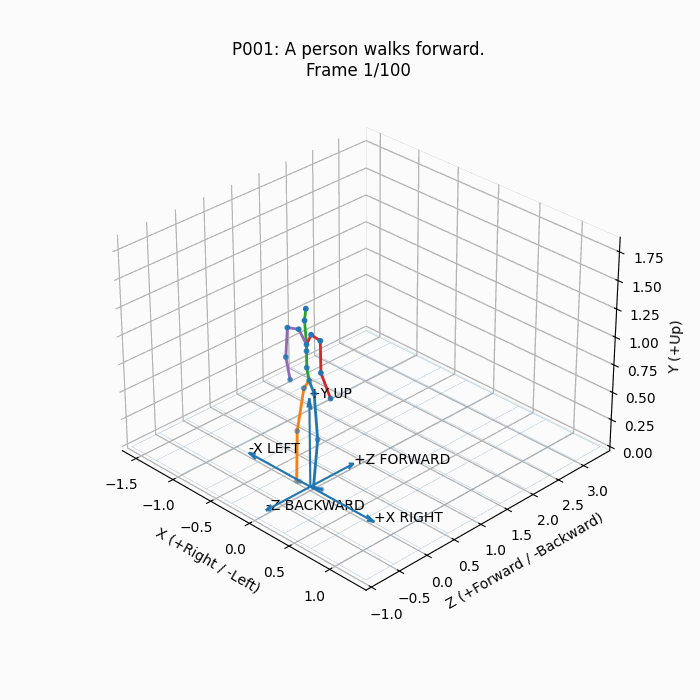

In [ ]:
import numpy as np
from IPython.display import Image, display

# Render one clip first to confirm the camera and axis labels look right.
row = standard_report.iloc[0]
preview_gif = cfg.std_gif_root / f"{row['Prompt_ID']}_preview.gif"

render_standard_gif(np.load(row["Standard_Joint_File"]), preview_gif,
                    row["Prompt_ID"], row["Prompt"], fps=20)

display(Image(filename=str(preview_gif)))

In [ ]:
# Render the whole batch and build the GIF report.
gif_report = cfg.render(standard_report, fps=20)

final_report = standard_report.merge(gif_report, on="Prompt_ID", how="left")
final_report.to_csv(cfg.report_file, index=False)

print("Saved report:", cfg.report_file)
final_report


Rendering P001 ...
P001: X=[-1.63, 1.37], Z=[-1.00, 3.44], Y=[0.00, 1.84]
Saved: /content/MotionHiFlow/standardised/pilot13_len100_v1/gifs/P001.gif

Rendering P002 ...
P002: X=[-1.50, 1.50], Z=[-1.61, 1.39], Y=[0.00, 2.04]
Saved: /content/MotionHiFlow/standardised/pilot13_len100_v1/gifs/P002.gif

Rendering P003 ...
P003: X=[-1.94, 1.18], Z=[-1.00, 3.24], Y=[0.00, 1.81]
Saved: /content/MotionHiFlow/standardised/pilot13_len100_v1/gifs/P003.gif

Rendering P004 ...
P004: X=[-1.09, 1.95], Z=[-1.00, 2.96], Y=[0.00, 1.81]
Saved: /content/MotionHiFlow/standardised/pilot13_len100_v1/gifs/P004.gif

Rendering P005 ...
P005: X=[-1.48, 1.52], Z=[-1.00, 3.08], Y=[0.00, 1.83]
Saved: /content/MotionHiFlow/standardised/pilot13_len100_v1/gifs/P005.gif

Rendering P006 ...
P006: X=[-1.57, 1.43], Z=[-1.00, 4.04], Y=[0.00, 1.83]
Saved: /content/MotionHiFlow/standardised/pilot13_len100_v1/gifs/P006.gif

Rendering P007 ...
P007: X=[-1.58, 1.42], Z=[-1.49, 1.51], Y=[0.00, 2.17]
Saved: /content/MotionHiFlow/st

,Prompt_ID,Prompt,Raw_Joint_File,Standard_Joint_File,Frames,Ground_Y,Initial_Root_X,Initial_Root_Z,Initial_Forward_X,Initial_Forward_Z,Facing_Angle_Deg,Facing_Status,GIF_File,GIF_Frames
0,P001,A person walks forward.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,0.092440,0.995718,5.303980,OK_+Z,/content/MotionHiFlow/standardised/pilot13_len...,100
1,P002,A person jumps once.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,-0.063331,0.997993,-3.631026,OK_+Z,/content/MotionHiFlow/standardised/pilot13_len...,100
2,P003,A person walks to the left.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,-0.116399,0.993203,-6.684300,OK_+Z,/content/MotionHiFlow/standardised/pilot13_len...,100
3,P004,A person walks forward and makes a right turn.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,0.027802,0.999613,1.593127,OK_+Z,/content/MotionHiFlow/standardised/pilot13_len...,100
4,P005,A person walks slowly forward.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,0.020560,0.999789,1.178068,OK_+Z,/content/MotionHiFlow/standardised/pilot13_len...,100
5,P006,A person walks quickly forward.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,0.020581,0.999788,1.179279,OK_+Z,/content/MotionHiFlow/standardised/pilot13_len...,100
6,P007,A person jumps once and then turns right.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,-0.042491,0.999097,-2.435272,OK_+Z,/content/MotionHiFlow/standardised/pilot13_len...,100
7,P008,"A person walks forward, jumps once, and then t...",/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,0.042646,0.999090,2.444190,OK_+Z,/content/MotionHiFlow/standardised/pilot13_len...,100
8,P009,A person walks forward and then turns right.,/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,-0.009280,0.999957,-0.531702,OK_+Z,/content/MotionHiFlow/standardised/pilot13_len...,100
9,P010,"A person walks backward, jumps twice, and then...",/content/MotionHiFlow/benchmark_runs/pilot13_l...,/content/MotionHiFlow/standardised/pilot13_len...,100,0.0,-0.0,0.0,-0.176336,0.984330,-10.156401,OK_+Z,/content/MotionHiFlow/standardised/pilot13_len...,100


In [ ]:
from google.colab import files

zip_path = package_gifs(cfg.std_gif_root, f"/content/gifs_{cfg.run_tag}")
print("ZIP created:", zip_path)
files.download(zip_path)

ZIP created: /content/gifs_pilot13_len100_v1.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Matching Score (optional)

Per-prompt distance between the text and the generated motion in the official evaluator's
shared embedding space. **Lower is better.**

This is a **per-prompt diagnostic**: it shows which individual prompts the model handled
badly. It is not the official benchmark protocol — paper-grade FID / R-Precision come from
the full HumanML3D evaluation, which needs the complete dataset and is outside the scope of
this notebook.

**Length constraints:** the evaluator's input is hard-fixed at 196 frames. Above that,
`MatchingScorer.score` raises rather than truncating silently; below ~40 frames it warns.
Most importantly, a score's absolute value shifts systematically with motion length, so
scores are **only comparable across prompts at the same length** — never read a 100-frame
score against a 196-frame one.

In [ ]:
%cd /content/MotionHiFlow

# spaCy provides the POS tags required by the HumanML3D text preprocessing.
!python -m spacy download en_core_web_sm -q

# Loading the evaluator takes a moment; do it once and reuse the object.
# For another repository, point the import paths at its copy of the official evaluator:
#   MatchingScorer(repo_root=..., evaluator_import="path.to.module:ClassName", ...)
scorer = MatchingScorer(repo_root="/content/MotionHiFlow", feature_dim=cfg.feature_dim)
print("Evaluator ready on", scorer.device)

/content/MotionHiFlow
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 99.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Loading Evaluation Model Wrapper (Epoch 28) Completed!!
Evaluator ready on cuda:0


In [ ]:
# cfg.score passes this run's naming convention through to the scorer.
df_scores = cfg.score(scorer, manifest)

if not df_scores.empty:
    # Aggregate per capability to see which instruction type is weakest.
    print("\nMean score per capability (lower is better):")
    display(df_scores.groupby("Capability")["Matching_Score"].agg(["mean", "count"]).round(4))

    df_scores.to_csv(cfg.score_csv, index=False)
    print("Saved:", cfg.score_csv)

df_scores

P001 | 1.0827 | 100f | A person walks forward.
P002 | 1.0630 | 100f | A person jumps once.
P003 | 0.9799 | 100f | A person walks to the left.
P004 | 1.0398 | 100f | A person walks forward and makes a right turn.
P005 | 1.2648 | 100f | A person walks slowly forward.
P006 | 1.0553 | 100f | A person walks quickly forward.
P007 | 0.9381 | 100f | A person jumps once and then turns right.
P008 | 2.5288 | 100f | A person walks forward, jumps once, and then turns right.
P009 | 1.3041 | 100f | A person walks forward and then turns right.
P010 | 2.3634 | 100f | A person walks backward, jumps twice, and then turns right.
P011 | 1.8879 | 100f | A person raises the left hand above the head.
P012 | 2.7321 | 100f | A person walks forward while raising the right hand.
P013 | 3.0577 | 100f | The person moves straight ahead before making a right turn.

Scored at: [100] frames
Reminder: do not compare these against scores from another motion_length.

Mean score per capability (lower is better):


,mean,count
Capability,,
C1 Basic Action,1.0728,2
C2 Spatial Control,1.3025,3
C3 Attribute Control,1.1600,2
C4 Event Structure,1.7334,2
C5 Composition,2.3643,4


Saved: /content/MotionHiFlow/standardised/pilot13_len100_v1/matching_scores.csv


,Prompt_ID,Capability,Prompt,Motion_File,Scored_Frames,Matching_Score
0,P001,C1 Basic Action,A person walks forward.,sample0_r0_len100_data.npy,100,1.0827
1,P002,C1 Basic Action,A person jumps once.,sample1_r0_len100_data.npy,100,1.0630
2,P003,C2 Spatial Control,A person walks to the left.,sample2_r0_len100_data.npy,100,0.9799
3,P004,C2 Spatial Control,A person walks forward and makes a right turn.,sample3_r0_len100_data.npy,100,1.0398
4,P005,C3 Attribute Control,A person walks slowly forward.,sample4_r0_len100_data.npy,100,1.2648
5,P006,C3 Attribute Control,A person walks quickly forward.,sample5_r0_len100_data.npy,100,1.0553
6,P007,C4 Event Structure,A person jumps once and then turns right.,sample6_r0_len100_data.npy,100,0.9381
7,P008,C4 Event Structure,"A person walks forward, jumps once, and then t...",sample7_r0_len100_data.npy,100,2.5288
8,P009,C5 Composition,A person walks forward and then turns right.,sample8_r0_len100_data.npy,100,1.3041
9,P010,C5 Composition,"A person walks backward, jumps twice, and then...",sample9_r0_len100_data.npy,100,2.3634


## Done

A successful end-to-end run produces generated motions and preview videos, standardised
`.npy` files with comparison GIFs and `standardisation_report.csv`, and per-prompt
`matching_scores.csv`.

### Key output paths

```
/content/
├── benchmark_utils.py                  # all reusable logic lives here
└── MotionHiFlow/
    ├── benchmark_runs/<run_tag>/t2m_tmdit_16d/
    │   ├── joints/       # (T, 22, 3) raw joint positions
    │   └── animations/   # (T, 263) features plus mp4 previews
    └── standardised/<run_tag>/
        ├── joints/                        # standardised .npy
        ├── gifs/                          # comparison GIFs
        ├── standardisation_report.csv
        └── matching_scores.csv
```

`<run_tag>` is `<run_name>_len<effective_length>_<run_version>`, e.g. `pilot13_len100_v1`,
so results from different motion lengths never share a directory.

### Changing behaviour

- **A run parameter** (length, batch name, version) → edit the `RunConfig(...)` call in Step 7.
- **The prompt set** → edit `BENCHMARK_PROMPTS` in Step 8.
- **Post-processing logic** (standardisation, rendering, scoring) → edit
  `benchmark_utils.py`. `autoreload` picks the change up on the next cell run; no restart
  and no re-running of earlier steps.
- **Generation itself** → pass different arguments to `run.sh`. Do not edit the repository's
  `gen_t2m.py`, or `git pull` will start conflicting.

---

## Porting to another text-to-motion model

The post-processing is model-agnostic **as long as the model emits the HumanML3D layout**:
`(T, 22, 3)` joint positions and `(T, 263)` feature vectors, Y up. What differs between
repositories is naming and coordinate convention, and those are constructor arguments — no
edits to `benchmark_utils.py` are needed.

```python
cfg = RunConfig(
    motion_length=100,
    root=Path("/content/OtherModel"),

    # --- repository layout ---
    experiment_name="my_experiment",                 # output sub-directory
    joints_subdir="joints",
    anim_subdir="animations",
    sample_pattern="sample{index}_r0_len{length}",   # filename stem; format specs are fine,
                                                     # e.g. "gen_{index:02d}_f{length:04d}"
    feature_suffix="_data",
    exclude_suffixes=("_ik",),                       # variants to ignore
    length_multiple=4,                               # what the model rounds lengths to

    # --- data convention ---
    n_joints=22,
    feature_dim=263,
    mirror_x=True,       # False if the model already emits +X = Right
)
```

For the matching score, point the import paths at that repository's copy of the evaluator.
The evaluator itself is the shared official HumanML3D one — MDM, MLD, T2M-GPT and others
all use it — so only its location changes:

```python
scorer = MatchingScorer(
    repo_root="/content/OtherModel",
    evaluator_import="src.evaluators.t2m_eval_wrapper:EvaluatorModelWrapper",
    vectorizer_import="src.utils.word_vectorizer:WordVectorizer",
    metrics_import="src.utils.metrics:euclidean_distance_matrix",
    evaluators_subdir="deps/evaluators",
    glove_subdir="deps/glove",
)
```

### What breaks loudly, and what does not

A wrong joint count or feature width raises immediately, so those mistakes are safe.

**`mirror_x` is the exception.** Nothing can infer it: the facing check only measures the
angle to `+Z`, which a left-right flip leaves unchanged, so a wrong value yields a
perfectly plausible result with left and right swapped throughout. Always verify it with
`check_left_right_convention()` on a "walks to the left" clip — Step 9 does this
automatically — or by watching one GIF against the `-X LEFT` label drawn in the frame.